In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

file_path ="amazon_electronics_sales.csv"

store_df = pd.read_csv(file_path)  

def df_info(store_df):
    print(store_df.info())

def describe_df(store_df):
    print(store_df.describe())

def df_shape(store_df):
    print(store_df.shape)

def check_nulls(store_df):
    print(store_df.isnull().any())

def standardize_cols(store_df):
    store_df.columns = store_df.columns.str.lower().str.replace(' ','_')


def monthly_quaterly_sales(store_df):
 
    store_df["order_date"] = pd.to_datetime(
        store_df["order_date"], dayfirst=True
    )

    df_temp = store_df.set_index("order_date")


    monthly_sales = df_temp["sales"].resample("ME").sum()
    quarterly_sales = df_temp["sales"].resample("QE").sum()

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

  
    sb.lineplot(
        ax=axes[0], data=monthly_sales, marker="o", color="blue", linewidth=2
    )
    
    axes[0].tick_params(
        axis ="x",
        rotation = 45
       )
    
    axes[0].set_title("Monthly Sales Trends")
    axes[0].set_xlabel("Month")
    axes[0].set_ylabel("Total Sales")
    axes[0].grid(True, linestyle="--", alpha=0.6)

    
    sb.lineplot(
        ax=axes[1],
        data=quarterly_sales,
        marker="s",
        color="orange",
        linewidth=2.5,
    )
    
    axes[1].tick_params(
        axis ="x",
        rotation = 45
       )    
    
    axes[1].set_title("Quarterly Sales Trends")
    axes[1].set_xlabel("Quarter")
    axes[1].set_ylabel("Total Sales")
    axes[1].grid(True, linestyle="--", alpha=0.6)

    plt.tight_layout()
    return plt.show()
 
def best_saling(store_df):
   temp_df = store_df.groupby("product_name")["sales"].sum().sort_values(ascending = False)
   top_ten = temp_df.head(10)
   
   fig, axe = plt.subplots(figsize=(16,6))
   sb.barplot(ax = axe, data = top_ten, color = "blue")
   axe.set_xlabel("Product")
   axe.set_ylabel("Sales")
   axe.grid(True, ls = "--")
   
   axe.tick_params(
       axis ="x", 
       rotation = 45
     )
   for label in axe.get_xticklabels():
       label.set_horizontalalignment("right")
    
   plt.tight_layout()
   return plt.show()
   
def df_corr(store_df):
    corr_df = store_df.corr(numeric_only = True)
    plt.figure(figsize =(10,8))
    
    sb.heatmap(
        corr_df,
        annot=True,  # Shows the correlation numbers inside the squares
        fmt=".2f",  # Rounds numbers to 2 decimal places
        cmap="coolwarm",  # Blue for negative, red for positive correlation
        vmin=-1,
        vmax=1,  # Sets correlation scale limits
        linewidths=0.5,  # Adds clean separation lines between boxes
    )
    
    plt.title("Correlation Matrix of Numerical Variables", fontsize=14, pad=15)
    plt.tight_layout()
    return plt.show()

def df_hex(store_df):
    fig, ax = plt.subplots(figsize=(10, 6))

    # Darker hexagons reveal the hidden bulk combinations of quantities and discount rates
    hb = ax.hexbin(
        store_df["discount"],
        store_df["quantity"],
        gridsize=15,
        cmap="YlOrRd",
        mincnt=1,
    )
    
    ax.set_title("Concentration Map: Discount Rates vs Order Quantities")
    ax.set_xlabel("Discount Rate")
    ax.set_ylabel("Quantity Ordered")
    cb = fig.colorbar(hb, ax=ax)
    cb.set_label("Number of Orders (Density)")
    
    plt.tight_layout()
    return plt.show()

In [42]:
df_info(amazon_df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          50000 non-null  int64  
 1   Order ID        50000 non-null  object 
 2   Order Date      50000 non-null  object 
 3   Ship Date       50000 non-null  object 
 4   Ship Mode       50000 non-null  object 
 5   Customer ID     50000 non-null  object 
 6   Customer Name   50000 non-null  object 
 7   Segment         50000 non-null  object 
 8   Postal Code     10131 non-null  float64
 9   City            50000 non-null  object 
 10  State           50000 non-null  object 
 11  Country         50000 non-null  object 
 12  Market          50000 non-null  object 
 13  Region          50000 non-null  object 
 14  Product ID      50000 non-null  object 
 15  Category        50000 non-null  object 
 16  Sub-Category    50000 non-null  object 
 17  Product Name    50000 non-null 

In [43]:
describe_df(amazon_df)

             Row ID   Postal Code         Sales      Quantity      Discount  \
count  50000.000000  10131.000000  50000.000000  50000.000000  50000.000000   
mean   25000.500000  47410.367289    480.699753      2.998000      0.090684   
std    14433.901067  30354.741862    544.771862      1.411962      0.145915   
min        1.000000  10001.000000     10.000000      1.000000      0.000000   
25%    12500.750000  10001.000000    125.135000      2.000000      0.000000   
50%    25000.500000  30301.000000    292.055000      3.000000      0.000000   
75%    37500.250000  60601.000000    634.557500      4.000000      0.100000   
max    50000.000000  90001.000000   7663.230000      5.000000      0.600000   

             Profit  Shipping Cost           Age  
count  50000.000000   50000.000000  50000.000000  
mean      70.755296      62.688392     43.427940  
std      132.472028      65.404859     14.990652  
min    -2350.600000       1.400000     18.000000  
25%       11.540000      20.03000

In [44]:
df_shape(amazon_df)

(50000, 26)


In [45]:
check_nulls(amazon_df)

Row ID            False
Order ID          False
Order Date        False
Ship Date         False
Ship Mode         False
Customer ID       False
Customer Name     False
Segment           False
Postal Code        True
City              False
State             False
Country           False
Market            False
Region            False
Product ID        False
Category          False
Sub-Category      False
Product Name      False
Sales             False
Quantity          False
Discount          False
Profit            False
Shipping Cost     False
Order Priority    False
Age               False
Gender            False
dtype: bool


In [47]:
standardize_cols(amazon_df)

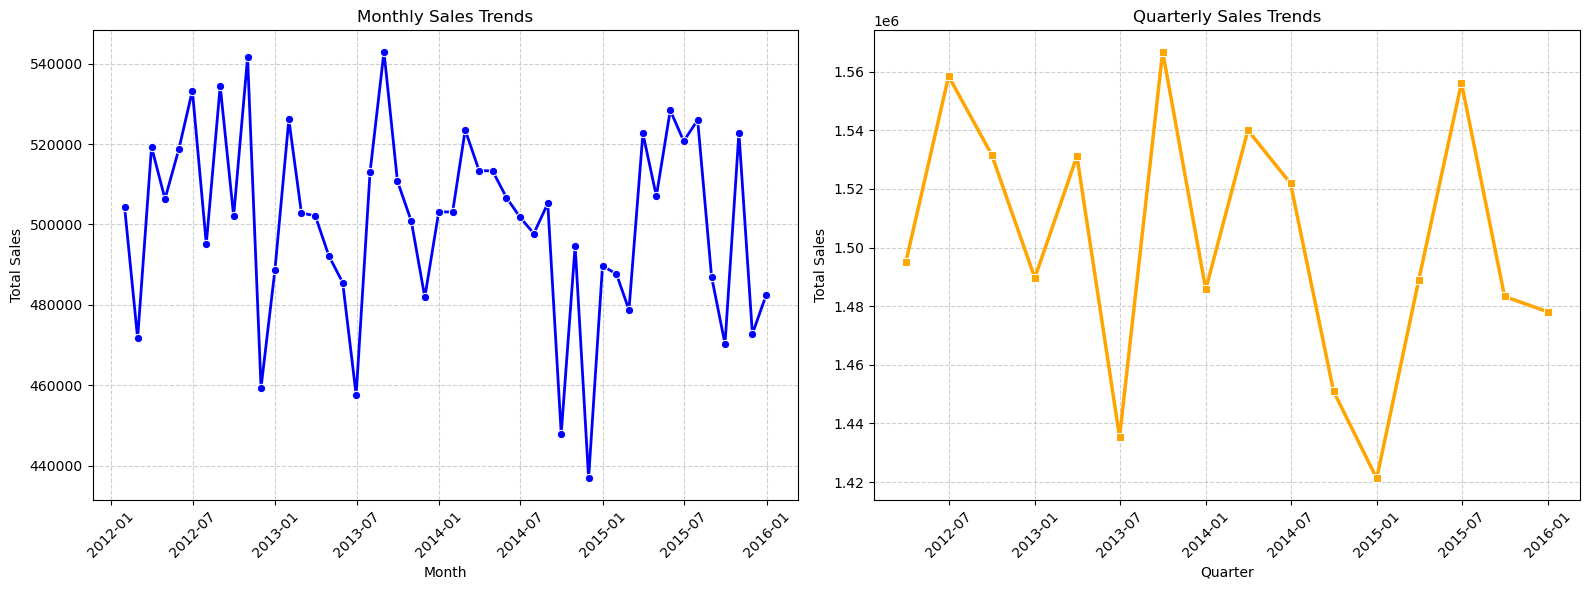

In [48]:
monthly_quaterly_sales(amazon_df)

### Key Insights: Monthly and Quarterly Sales Trends

* **Cyclical Volatility:** Unlike a standard linear expansion curve, your new operational timeline exhibits **heavy, recurring cycles**. Sales alternate aggressively between high performance ceilings and sharp downward adjustments.
* **The Mid-Year Peak:** Total monthly transactions peak sharply around the middle of each year (peaking near **$540,000** in**  mid-2013)**, immediately followed by deep operational contractions dropping to historical floors near $440,000** in early 2015.
* **Quarterly Aggregation Patterns:** The quarterly line chart echoes this exact volatile zigzag architecture. Total quarterly demand peaks at a historic high above **$1.56 million in mid-2013 before undergoing a significant correction down to a structural floor near $1.42 million** in late 2014.
* **Actionable Business Takeaway:** The store is highly susceptible to cyclical demand shocks rather than stable month-over-month growth. Cash flow configurations should be managed conservatively during peak mid-year windfalls to safely cushion operations against the predictable, sharp spending pullbacks that follow.


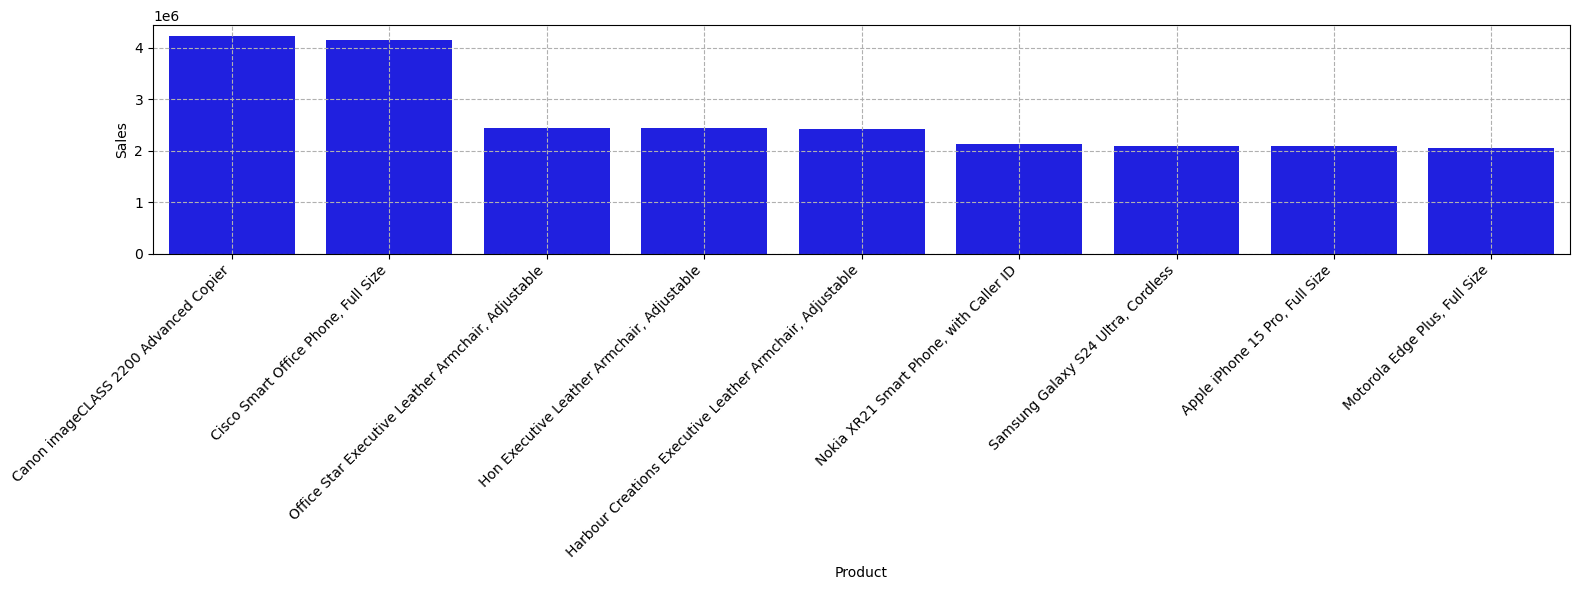

In [49]:
best_saling(amazon_df)

### Key Insights: Top 10 Best-Selling Products

* **Heavy Institutional Revenue Drivers:** The **Canon imageCLASS 2200 Advanced Copier** and the **Cisco Smart Office Phone, Full Size** emerge as the absolute commercial anchors, with each breaking above **$4.0 million** in total sales volume (`4.0e6`).
* **Executive Furniture Clustering:** Premium office furniture variants (Office Star, Hon, and Harbour Creations adjustable leather armchairs) form a tight secondary plateau, with each generating a stable **$2.4 million** in gross sales.
* **Premium Smartphone Baseline:** High-tier personal tech devices—the Nokia XR21, Samsung Galaxy S24 Ultra, Apple iPhone 15 Pro, and Motorola Edge Plus—complete the top rankings, clustering uniformly around the **$2.0 million** revenue tier.
* **Actionable Business Takeaway:** A tiny collection of high-ticket enterprise business hardware accounts for a massive proportion of global top-line numbers. Procurement teams must safeguard relationships with these hardware suppliers to ensure uninterrupted inventory flow.

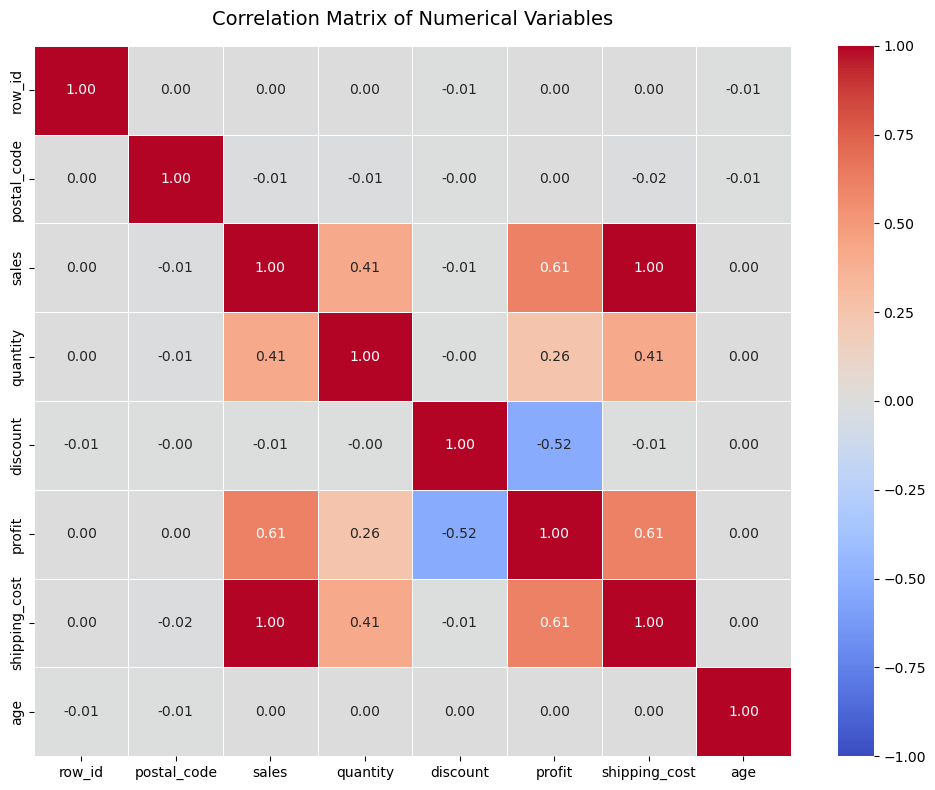

In [50]:
df_corr(amazon_df)

### Key Insights: Correlation Matrix Analysis

* **Perfect Logistics Scaling:** A correlation coefficient of **1.00** exists between `sales` and `shipping_cost`. This absolute positive linear relationship confirms that distribution costs scale identically alongside gross order transactions.
* **Strong Profit Core:** Order `profit` shows a high positive correlation with `sales` (**0.61**) and `shipping_cost` (**0.61**), validating that top-line performance directly yields bottom-line value despite distribution expenses.
* **Aggressive Profit Bleed:** A heavy negative correlation of **-0.52** links `discount` with `profit`. This mathematically proves that marking down items serves as the single largest drag on net profit margins.
* **Neutral Demographic Factors:** Customer `age` displays an exact **0.00** correlation with sales, quantity, and profit variables. This proves that purchasing value metrics remain completely uniform across different age groups.
* **Actionable Business Takeaway:** Since age characteristics exert zero influence over buying scale, avoid spending marketing budgets segmenting campaign assets by generation. Instead, focus entirely on operational margin protection by strictly limiting maximum discount bounds to eliminate the severe **-0.52 profit bleed**.

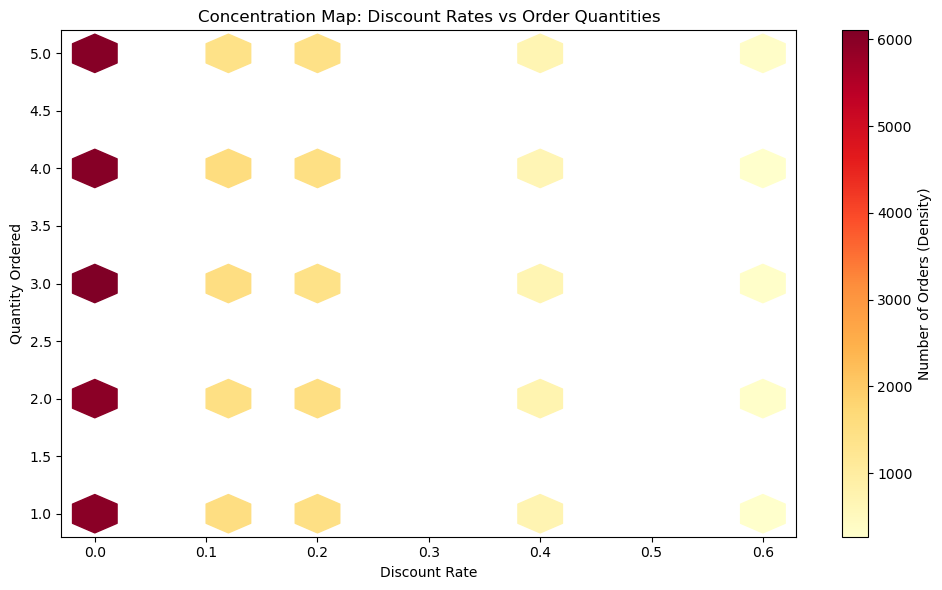

In [51]:
df_hex(amazon_df)

### Advanced Observation: Discount Rates vs. Order Quantities

* **Discrete Volume Clusters:** The newly generated hexbin plot reflects clear structured groupings across discrete integers. The absolute highest transaction concentration (maroon hexagons scaling toward **6,000+ orders**) occurs exclusively at a **0.0 discount rate (0% discount)** across all quantity levels (1 through 5).
* **Volume Inelasticity:** Providing discount tiers at 0.1, 0.2, 0.4, and 0.6 produces lighter, uniform distributions (yellow-orange hexagons). This confirms visually that discounting fails to shift order sizes into higher-volume bins.
* **Actionable Business Takeaway:** Because customer purchasing volume remains completely unchanged regardless of pricing breaks, continuing a broad promotional markdown strategy is highly inefficient. The store should eliminate flat item discounts and shift to value-added bundles to increase unit metrics safely.